# Expfit notes 1X: Initial guess single - old method - no longer used


## H1: Initial guess for a single exponential

\begin{align}
y(x)  &= a + b e^{c x} \\
y'(x) &= c b e^{c x}
\end{align}

**Given** two points $(x_1, y_1)$ and $(x_2, y_2)$ and their slopes $y_1'$ and $y_2'$
\begin{align}
y_1  - y_2  &= b (e^{c x_1} - e^{c x_2}) \\
y_1' - y_2' &= c b (e^{c x_1} - e^{c x_2}) \\
c &= \frac{y_1' - y_2'}{y_1 - y_2}
\end{align}
and
\begin{align}
a &= y_i - y'_i / c \\
b &= (y_i - a) / e^{c x_i}
\end{align}
for $i \in {1, 2}$

To choose $i$ we assume the steepest side of the exponential has the best signal-to-noise ratio, so
\begin{align}
i=\begin{cases} 0, & c < 0\\ 1, & c \geq 0 \end{cases}
\end{align}

**Edge case:** If $y_1 - y_2 = 0$ (exactly), we get a divide by zero so return `a = mean(y), b = 0, c = 0`.

## HX: Finding two points and their derivatives

To find $(x_1, y_1, y_1')$ and $(x_2, y_2, y_2')$ we select a segment $S_1$ at the start of the data, and a segment $S_2$ at the end of the data.

1. $x_i$ and $y_i$ are the mean of $t$ and $v$ on $S_i$
2. $y_i'$ is found by fitting a straight line to $S_i$ with linear least squares


### HXa: Initial choice of segments

To choose $S_1$ and $S_2$, we make an initial guess based on the length, $n$, of the time series

| Length   | Strategy                                                 |
|----------|----------------------------------------------------------|
| n < 10   | Use left and right half, possibly overlapping by 1 point |
| n < 100  | Start with left and right half, then refine (see below)  |
| n < 1000 | Start with left 3d and right 3d, then refine             |
| else     | Start with left 10% and right 10%, then refine           |

**Magic numbers**: Cut-offs, chosen segments

### HXb: Refining to find linear segments

We want $S_1$ and $S_2$ to be
- short enough that a straight line fit matches the slope of the exponential
- as long as possible, so that the fit denoises the signal

To do this, we successively shorten our initial segments, and fit straight lines, until the residuals look like noise.
To judge this, we look at the residuals' lag-1 autocorrelation, and test if its Pearson correlation coefficient is low.

```
a, b = least_squares(x, y)

while len(x) > 5:
    residuals = y - (a + b * x)
    if PearsonR2(residuals[1:], residuals[:-1]) < 0.1
        break
    else
        select left (S1) or right (S2) half of segment
        a, b = least_squares(x, y)

return a, b
```

**Edge cases:** We stop without meeting the criterion if the segment gets shorter than 5 data points

**Magic numbers:** minimum length 5, $R^2$ cut-off 0.1, shrinking factor $1/2$

### Demo: Initial guess for single exponential

First, show the selected segments

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import expfit

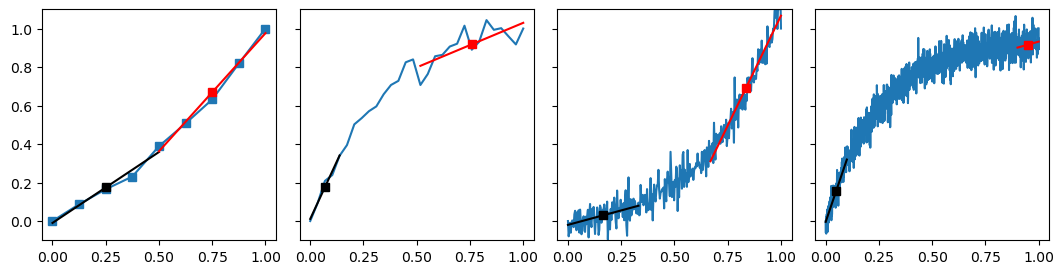

In [2]:
rng = np.random.default_rng(1)

def f(x, a, b, c):
    return a + b * np.exp(c * x)

def fn(x, a, b, c, s):
    y = f(x, a, b, c) + rng.normal(0, s, len(x))
    return (y - y[0]) / (y[-1] - y[0])

tests = [
    (3, 2, 1, 0.07, 9),
    (-1, -2, -3, 0.08, 30),
    (-3, 5, 3, 5, 300),
    (4, -2, -4, 0.1, 1200),
]

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fn(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax)

plt.show()

In this example (random seed 1), the second segment isn't ideal: due to the low signal-to-noise ratio in this part of the graph, the estimated slope is way off.
The fourth example suffers from this a little too.

Note that we have normalised the data here, causing all examples (note the different signs etc.) to look very similar

Now, we run again showing the initial guesses.

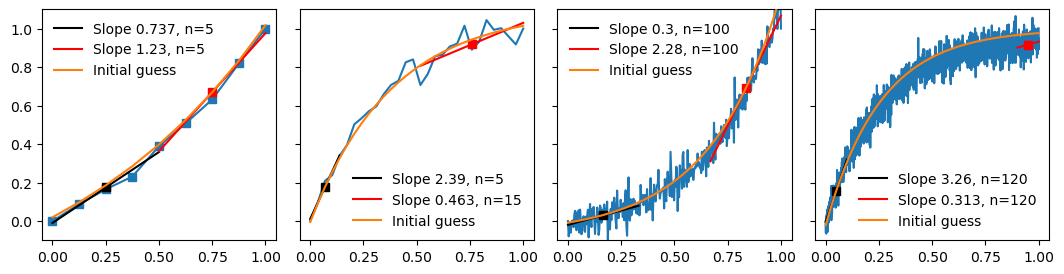

In [3]:
rng = np.random.default_rng(1)

def fn(x, a, b, c, s):
    y = f(x, a, b, c) + rng.normal(0, s, len(x))
    return (y - y[0]) / (y[-1] - y[0])

fig = plt.figure(figsize=(13, 3))
fig.subplots_adjust(wspace=0.1)
grd = fig.add_gridspec(1, 4)
for i, (a, b, c, s, n) in enumerate(tests):
    x = np.linspace(0, 1, n)
    y = fn(x, a, b, c, s)

    ax = fig.add_subplot(grd[i])
    ax.plot(x, y, 's-' if n < 10 else '-')
    a0, b0, c0 = expfit.estimate_initial_single(x, y, axes=ax)
    ax.plot(x, f(x, a0, b0, c0), label='Initial guess', zorder=10)
    ax.legend(frameon=False)
    ax.set_ylim(-0.1, 1.1)
    if i > 0:
        ax.set_yticklabels([])

plt.show()

So despite the noisy $S_2$ in the 2nd panel, the initial estimate is still OK: an optimiser should easily be able to fit this.

### HXc: Sanity checks and fallbacks

Finally, we add checks to stop if a segment doesn't meet the criteria expected of an exponential.

1. We expect both segments to have a slope with the same sign as full signal. If a segment violates this assumption, it is rejected and replaced by the fallback segment.
2. We expect one segment to have a smaller slope (in absolute terms) than the full signal, and one to have a greater slope. If this assumption is violated, both segments are rejected and replaces by the fallbacks.

The fallback segments are simply half the signal, plus 1 point (the same as used when n<10).

3. If a fallback segment has the wrong sign slope, it is set to zero.

The rationale here is that, if the "clever" method fails, we shouldn't try to be even cleverer but use a simpler, more robust method.

### Straight lines

Finally, if the input is a noisy flat line, the results of H1+HX are very unpredictable, and extremely sensitive to noise (as b tends to 0, c becomes unidentifiable, so possibly very large).
We check for this explicitly by comparing the RMSE of a flat line fit with the RMSE of the exponential fit, returning `mean(y), 0, 0` if the ratio > 2.

**Magic numbers: ratio 2**.

### Demo: fallback routines

In the first example, we've caught a bit of a fast transient at the start of the signal, leading to an impossible slope for a single exponential.
A second distortion has caused the end of the signal to slope down:

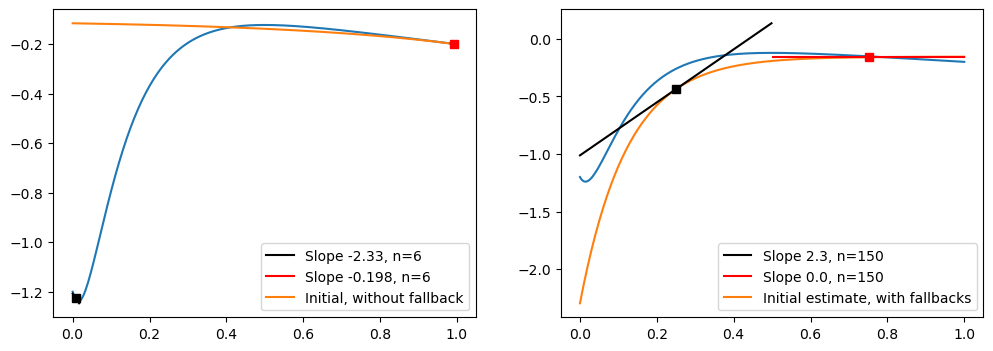

In [4]:
rng = np.random.default_rng(1)
a0, b0, c0 = 1, -2, -9
n = 300
x = np.linspace(0, 1, n)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.8 * np.exp(-30 * x)
y += -0.2 * x

def demo_fallbacks(x, y):
    fig = plt.figure(figsize=(12, 4))
    ax = fig.add_subplot(1, 2, 1)
    ax.plot(x, y)
    a, b, c = expfit.estimate_initial_single(x, y, axes=ax, use_fallbacks=False)
    ax.plot(x, a + b * np.exp(c * x), label='Initial, without fallback')
    ax.legend()
    ax = fig.add_subplot(1, 2, 2)
    ax.plot(x, y)
    a, b, c = expfit.estimate_initial_single(x, y, axes=ax, use_fallbacks=True)
    ax.plot(x, a + b * np.exp(c * x), label='Initial estimate, with fallbacks')
    ax.legend()

demo_fallbacks(x, y)
plt.show()

Note that the fit still won't be good: the start of the signal will distort the final result.

Next, a very contrived example, where a large sine causes both slopes to exceed the full signal slope:


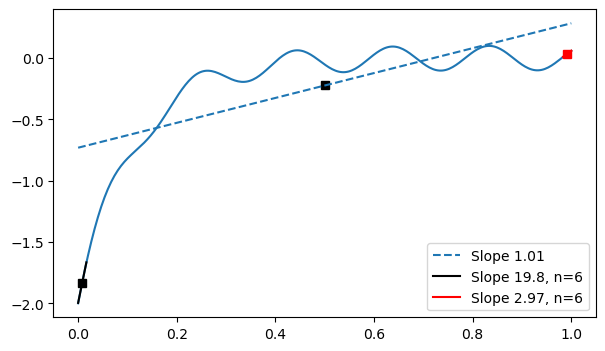

In [5]:
rng = np.random.default_rng(1)

a0, b0, c0 = 1, -2, -9
n = 300
x = np.linspace(0, 1, n)
y = a0 * np.zeros(x.shape)
y += b0 * np.exp(c0 * x)
y += 0.1 * np.sin(10.2 * np.pi * x)

xlo, ylo, olo, s0 = expfit.find_linear_segment(x[:100], y[:100], 5)
x0, y0 = np.mean(xlo), np.mean(ylo)
xhi, yhi, ohi, s1 = expfit.find_linear_segment(x[-100:], y[-100:], 5, left=False)
x1, y1 = np.mean(xhi), np.mean(yhi)
oall, sall = expfit.least_squares(x, y)
xall, yall = np.mean(x), np.mean(y)

fig = plt.figure(figsize=(7, 4))
ax = fig.add_subplot()
ax.plot(x, y)
ax.plot(xall, yall, 'ks')
ax.plot(x, oall + sall * x, 'tab:blue', ls='--', label=f'Slope {sall:.3}')
ax.plot(x0, y0, 'ks')
ax.plot(xlo, olo + s0 * xlo, 'k', label=f'Slope {s0:.3}, n={len(xlo)}')
ax.plot(x1, y1, 'rs')
ax.plot(xhi, ohi + s1 * xhi, 'r', label=f'Slope {s1:.3}, n={len(xhi)}')
ax.legend()
plt.show()

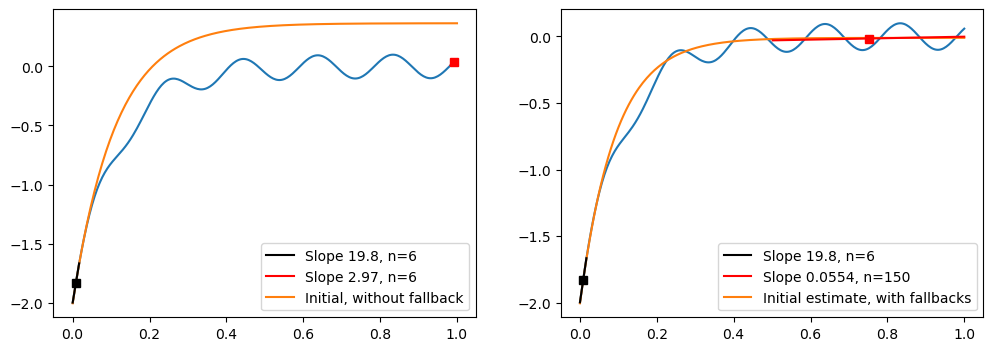

In [6]:
demo_fallbacks(x, y)
plt.show()

Next up, a straight line with noise:

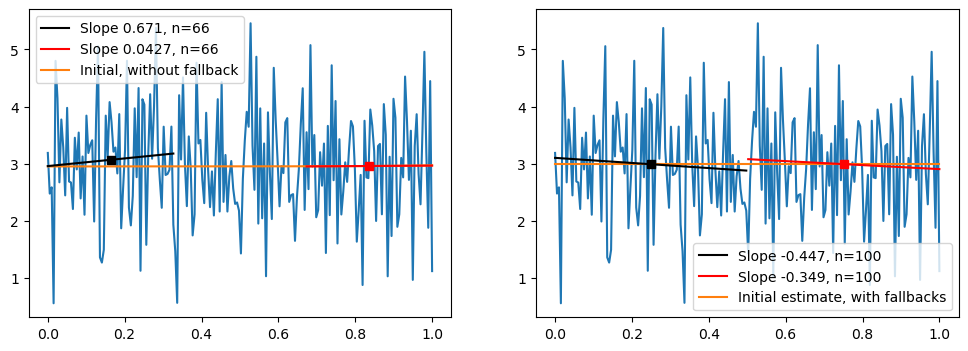

In [7]:
rng = np.random.default_rng(2)
n = 200
x = np.linspace(0, 1, n)
y = 3 + rng.normal(0, 1, x.shape)

demo_fallbacks(x, y)

And again, with a different random seed:

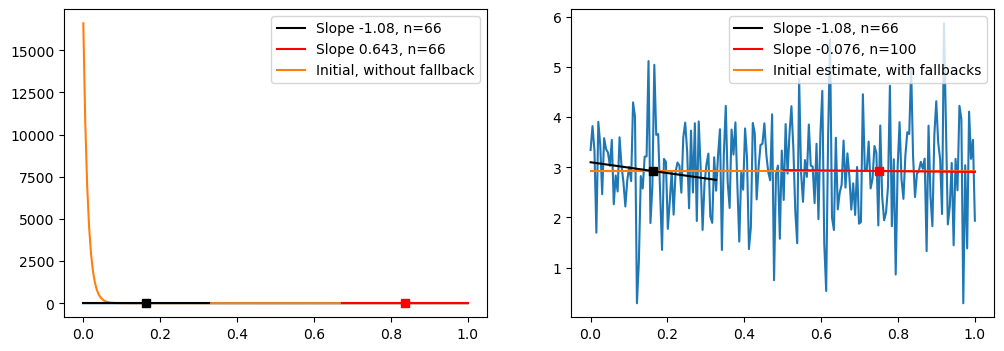

In [8]:
rng = np.random.default_rng(1)
y = 3 + rng.normal(0, 1, x.shape)

demo_fallbacks(x, y)

### Autocorrelated noise

Finally, since we based the method of finding straight segments on autocorrelated residuals, we can try adding some to see if it breaks the method:

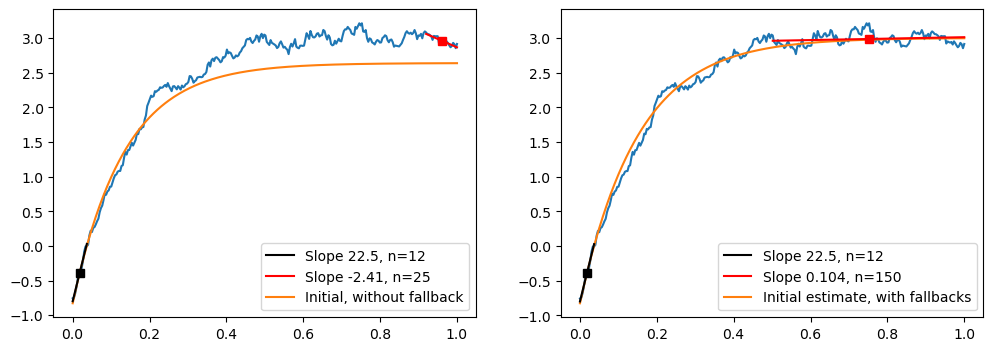

In [37]:
a0, b0, c0 = 3, -4, -7
x = np.linspace(0, 1, 300)
y = a0 + b0 * np.exp(c0 * x)

# Add AR1 noise (https://pints.readthedocs.io/en/stable/noise_generators.html)
rng = np.random.default_rng(5)
rho, sigma = 0.9, 0.1
s = sigma * np.sqrt(1 - rho**2)
v = rng.normal(0, s, len(x))
v[0] = rng.uniform()
for t in range(1, len(x)):
    v[t] += rho * v[t - 1]
y += v

demo_fallbacks(x, y)

Note that the fallbacks here kicked in because the sign of the slope (red) was wrong.
The method has no problem finding segments of the signal that don't look particularly autocorrelated!